# Individual Homework 05 — Adversarial Attacks, Poisoning, and Membership Inference in COMPAS

**Course:** DNSC 6330 Responsible Machine Learning  
**Student:** Zuleirys Santana Rodriguez  
**Lecture reference:** Lecture 05, `DNSC_6330_Lecture-05.pdf`

This notebook continues directly from the COMPAS workflow used in the earlier assignments and extends the Assignment 4 codebase into a security and abuse-pathways audit. Following Lecture 05, the notebook implements three applied attack analyses and a closing reflection:

1. **PGD evasion audit** on the logistic regression and gradient-boosted tree models
2. **Label-flip poisoning loop** with fairness monitoring
3. **Shadow-model membership inference** with a regularization sweep for logistic regression
4. **Reflection and mitigation analysis** based on the most consequential risk finding

The goal is not just to show that attacks exist. The goal is to measure how the attacks affect both predictive performance and fairness-oriented governance metrics on the COMPAS pipeline.

## Submission Checklist And Rubric Alignment

This notebook is structured to match the Lecture 05 grading guidance for the individual coding homework.

- **Correctness of implementation:** all required technical sections from the lecture homework are implemented directly in Python.
- **Code clarity and reproducibility:** the notebook is standalone, uses a local COMPAS CSV in the same folder, and runs top to bottom with fixed random seeds.
- **Interpretation quality:** every major section includes an interpretation block that explains what the outputs mean rather than only printing metrics.
- **Evidence of audit-level reasoning:** the notebook ends with a reflection section that identifies the highest-risk finding, proposes one proactive and one reactive mitigation, quantifies each mitigation, and discusses racial impact.

The lecture tasks covered here are:

1. PGD evasion over `epsilon in {0.25, 0.5, 1.0, 2.0}` for LR and GBT
2. Poisoning loop with fairness monitoring for African-American-targeted and Caucasian-targeted variants
3. Membership inference for LR and GBT, plus L2 regularization sweep for LR
4. Reflection with mitigation design and quantified impact

## Load Data And Rebuild The COMPAS Pipeline

Lecture 05 explicitly says to continue from the live coding pipeline and the Assignment 4 codebase. I therefore keep the same core COMPAS preprocessing and the same two baseline models used in the earlier homework: a logistic regression and a gradient-boosted tree.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 200)
RANDOM_STATE = 42

In [2]:
DATA_PATH = Path("compas-scores-two-years.csv")
FALLBACK_URL = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

if DATA_PATH.exists():
    raw_data = pd.read_csv(DATA_PATH)
    data_source = str(DATA_PATH)
else:
    raw_data = pd.read_csv(FALLBACK_URL)
    data_source = FALLBACK_URL

raw_data.shape, data_source

((7214, 53), 'compas-scores-two-years.csv')

In [3]:
def prepare_compas_frame(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df[
        [
            "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
            "priors_count", "days_b_screening_arrest", "decile_score",
            "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
        ]
    ].copy()

    df = df[df["days_b_screening_arrest"].between(-30, 30)]
    df = df[df["is_recid"] != -1]
    df = df[df["c_charge_degree"] != "O"]
    df = df[df["score_text"] != "N/A"].copy()

    for col in ["c_jail_in", "c_jail_out"]:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)
        df[f"{col}_num"] = df[col].map(lambda x: x.timestamp() if pd.notnull(x) else np.nan)
        df[f"{col}_num"] = df[f"{col}_num"].fillna(df[f"{col}_num"].median())

    df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
    df["length_of_stay"] = df["length_of_stay"].fillna(df["length_of_stay"].median())

    return df.reset_index(drop=True)


df = prepare_compas_frame(raw_data)
df.shape

(6172, 16)

In [4]:
target = "two_year_recid"

numeric_features = [
    "age",
    "priors_count",
    "decile_score",
    "days_b_screening_arrest",
    "is_recid",
    "c_jail_in_num",
    "c_jail_out_num",
    "length_of_stay",
]

categorical_features = [
    "age_cat",
    "sex",
    "race",
    "c_charge_degree",
    "score_text",
]

features = numeric_features + categorical_features
X = df[features].copy()
y = df[target].astype(int)

# Keep a separate shadow pool for membership inference while preserving a full target split.
X_target_pool, X_shadow_pool, y_target_pool, y_shadow_pool = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_target_pool,
    y_target_pool,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_target_pool,
)

feature_bounds = {feature: (X_train[feature].min(), X_train[feature].max()) for feature in numeric_features}

print(f"Target train shape: {X_train.shape}")
print(f"Target test shape: {X_test.shape}")
print(f"Shadow pool shape: {X_shadow_pool.shape}")

Target train shape: (3702, 13)
Target test shape: (1235, 13)
Shadow pool shape: (1235, 13)


In [5]:
def make_preprocessor() -> ColumnTransformer:
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", encoder, categorical_features),
        ]
    )


def build_lr_pipeline(C: float = 1.0, random_state: int = RANDOM_STATE) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("classifier", LogisticRegression(max_iter=1000, C=C, penalty="l2", random_state=random_state)),
        ]
    )


def build_gbt_pipeline(random_state: int = RANDOM_STATE) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=random_state)),
        ]
    )


lr_pipeline = build_lr_pipeline(C=1.0)
gbt_pipeline = build_gbt_pipeline()

lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'decile_score',
                                                   'days_b_screening_arrest',
                                                   'is_recid', 'c_jail_in_num',
                                                   'c_jail_out_num',
                                                   'length_of_stay']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [6]:
def eval_frame(X_eval: pd.DataFrame, y_eval: pd.Series, prob: np.ndarray, threshold: float = 0.5) -> pd.DataFrame:
    frame = X_eval[["race", "sex", "age_cat"]].copy()
    frame["actual"] = y_eval.to_numpy()
    frame["pred_prob"] = prob
    frame["pred"] = (prob >= threshold).astype(int)
    frame["pred_no_recid"] = 1 - frame["pred"]
    return frame


def fpr_by_group(frame: pd.DataFrame, group_col: str = "race") -> pd.DataFrame:
    rows = []
    for group, gdf in frame.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1]).ravel()
        rows.append(
            {
                group_col: group,
                "n": len(gdf),
                "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
                "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
                "selection_rate_no_recid": gdf["pred_no_recid"].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("n", ascending=False)


def air_by_race(frame: pd.DataFrame, reference: str = "Caucasian") -> pd.DataFrame:
    rates = frame.groupby("race")["pred_no_recid"].mean().rename("selection_rate_no_recid")
    ref_rate = rates.loc[reference]
    out = rates.reset_index()
    out["AIR_vs_Caucasian"] = out["selection_rate_no_recid"] / ref_rate
    return out.sort_values("AIR_vs_Caucasian")


def fairness_summary(frame: pd.DataFrame) -> dict:
    fpr_table = fpr_by_group(frame, group_col="race")
    air_table = air_by_race(frame)
    aa_air = air_table.loc[air_table["race"] == "African-American", "AIR_vs_Caucasian"].iloc[0]
    return {"fpr_table": fpr_table, "air_table": air_table, "aa_air": aa_air}


def performance_metrics(pipeline: Pipeline, X_eval: pd.DataFrame, y_eval: pd.Series) -> dict:
    prob = pipeline.predict_proba(X_eval)[:, 1]
    pred = pipeline.predict(X_eval)
    return {
        "auc": roc_auc_score(y_eval, prob),
        "accuracy": accuracy_score(y_eval, pred),
        "log_loss": log_loss(y_eval, prob),
        "prob": prob,
    }


baseline_rows = []
baseline_artifacts = {}
for model_name, pipeline in [("Logistic Regression", lr_pipeline), ("Gradient-Boosted Tree", gbt_pipeline)]:
    metrics = performance_metrics(pipeline, X_test, y_test)
    frame = eval_frame(X_test, y_test, metrics["prob"])
    fairness = fairness_summary(frame)
    baseline_artifacts[model_name] = {**metrics, **fairness}
    baseline_rows.append(
        {
            "model": model_name,
            "test_auc": metrics["auc"],
            "test_accuracy": metrics["accuracy"],
            "test_log_loss": metrics["log_loss"],
            "AA_AIR_vs_Caucasian": fairness["aa_air"],
        }
    )

baseline_table = pd.DataFrame(baseline_rows)
baseline_table

,model,test_auc,test_accuracy,test_log_loss,AA_AIR_vs_Caucasian
0,Logistic Regression,0.985477,0.965182,0.109971,0.768236
1,Gradient-Boosted Tree,0.982852,0.962753,0.128581,0.776438


In [7]:
for model_name in baseline_artifacts:
    display(Markdown(f"### Clean fairness baseline for {model_name}"))
    display(baseline_artifacts[model_name]["fpr_table"])
    display(baseline_artifacts[model_name]["air_table"])

### Clean fairness baseline for Logistic Regression

,race,n,fpr,fnr,selection_rate_no_recid
0,African-American,642,0.090615,0.0,0.437695
2,Caucasian,423,0.039841,0.0,0.569740
3,Hispanic,107,0.040541,0.0,0.663551
5,Other,56,0.000000,0.0,0.607143
4,Native American,4,0.500000,0.0,0.250000
1,Asian,3,0.333333,NaN,0.666667


,race,selection_rate_no_recid,AIR_vs_Caucasian
4,Native American,0.250000,0.438797
0,African-American,0.437695,0.768236
2,Caucasian,0.569740,1.000000
5,Other,0.607143,1.065649
3,Hispanic,0.663551,1.164657
1,Asian,0.666667,1.170124


### Clean fairness baseline for Gradient-Boosted Tree

,race,n,fpr,fnr,selection_rate_no_recid
0,African-American,642,0.090615,0.009009,0.442368
2,Caucasian,423,0.039841,0.000000,0.569740
3,Hispanic,107,0.040541,0.000000,0.663551
5,Other,56,0.000000,0.000000,0.607143
4,Native American,4,0.500000,0.000000,0.250000
1,Asian,3,0.333333,NaN,0.666667


,race,selection_rate_no_recid,AIR_vs_Caucasian
4,Native American,0.250000,0.438797
0,African-American,0.442368,0.776438
2,Caucasian,0.569740,1.000000
5,Other,0.607143,1.065649
3,Hispanic,0.663551,1.164657
1,Asian,0.666667,1.170124


## Part A — PGD Evasion Audit

Lecture 05 asks for a PGD audit on both the logistic regression and the gradient-boosted tree over `epsilon in {0.25, 0.5, 1.0, 2.0}`.

For tabular data, the attack is applied to the numeric feature block while keeping categorical values fixed. That means this section should be interpreted as a **model-vulnerability stress test**, not as a claim that every perturbed field is realistically manipulable in practice.

In [8]:
def binary_cross_entropy(y_true: np.ndarray, prob: np.ndarray) -> np.ndarray:
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    return -(y_true * np.log(prob) + (1 - y_true) * np.log(1 - prob))


def get_numeric_scaler(pipeline: Pipeline):
    return pipeline.named_steps["preprocessor"].named_transformers_["num"]


def reconstruct_from_z(base_frame: pd.DataFrame, z_matrix: np.ndarray, pipeline: Pipeline) -> pd.DataFrame:
    scaler = get_numeric_scaler(pipeline)
    X_adv = base_frame.copy()
    numeric_values = z_matrix * scaler.scale_ + scaler.mean_
    for idx, feature in enumerate(numeric_features):
        low, high = feature_bounds[feature]
        X_adv[feature] = np.clip(numeric_values[:, idx], low, high)
    return X_adv


def lr_loss_gradient_in_z(pipeline: Pipeline, X_adv: pd.DataFrame, y_true: np.ndarray) -> np.ndarray:
    scaler = get_numeric_scaler(pipeline)
    clf = pipeline.named_steps["classifier"]
    prob = pipeline.predict_proba(X_adv)[:, 1]
    weights_z = clf.coef_[0][:len(numeric_features)]
    return ((prob - y_true)[:, None] * weights_z[None, :])


def finite_difference_gradient_in_z(
    pipeline: Pipeline,
    base_frame: pd.DataFrame,
    y_true: np.ndarray,
    z_matrix: np.ndarray,
    lower: np.ndarray,
    upper: np.ndarray,
    fd_step: float = 0.05,
) -> np.ndarray:
    grad = np.zeros_like(z_matrix)
    for j in range(z_matrix.shape[1]):
        z_plus = z_matrix.copy()
        z_minus = z_matrix.copy()
        z_plus[:, j] = np.clip(z_plus[:, j] + fd_step, lower[:, j], upper[:, j])
        z_minus[:, j] = np.clip(z_minus[:, j] - fd_step, lower[:, j], upper[:, j])

        prob_plus = pipeline.predict_proba(reconstruct_from_z(base_frame, z_plus, pipeline))[:, 1]
        prob_minus = pipeline.predict_proba(reconstruct_from_z(base_frame, z_minus, pipeline))[:, 1]

        loss_plus = binary_cross_entropy(y_true, prob_plus)
        loss_minus = binary_cross_entropy(y_true, prob_minus)
        grad[:, j] = (loss_plus - loss_minus) / (2 * fd_step)
    return grad


def pgd_attack_numeric(
    pipeline: Pipeline,
    X_base: pd.DataFrame,
    y_true: pd.Series,
    epsilon: float,
    steps: int = 5,
    fd_step: float = 0.05,
) -> pd.DataFrame:
    if epsilon == 0:
        return X_base.copy()

    scaler = get_numeric_scaler(pipeline)
    z0 = scaler.transform(X_base[numeric_features])
    train_z = scaler.transform(X_train[numeric_features])
    lower = np.maximum(z0 - epsilon, train_z.min(axis=0))
    upper = np.minimum(z0 + epsilon, train_z.max(axis=0))
    z_adv = z0.copy()
    alpha = epsilon / steps
    y_array = y_true.to_numpy()

    is_lr = isinstance(pipeline.named_steps["classifier"], LogisticRegression)

    for _ in range(steps):
        X_adv = reconstruct_from_z(X_base, z_adv, pipeline)
        if is_lr:
            grad = lr_loss_gradient_in_z(pipeline, X_adv, y_array)
        else:
            grad = finite_difference_gradient_in_z(pipeline, X_base, y_array, z_adv, lower, upper, fd_step=fd_step)
        z_adv = np.clip(z_adv + alpha * np.sign(grad), lower, upper)

    return reconstruct_from_z(X_base, z_adv, pipeline)


epsilons = [0.0, 0.25, 0.5, 1.0, 2.0]
pgd_summary_rows = []
pgd_fpr_rows = []
pgd_air_rows = []

for model_name, pipeline in [("Logistic Regression", lr_pipeline), ("Gradient-Boosted Tree", gbt_pipeline)]:
    for epsilon in epsilons:
        attacked_X = pgd_attack_numeric(pipeline, X_test, y_test, epsilon=epsilon, steps=5)
        attacked_prob = pipeline.predict_proba(attacked_X)[:, 1]
        attacked_frame = eval_frame(attacked_X, y_test, attacked_prob)
        fairness = fairness_summary(attacked_frame)
        auc_value = roc_auc_score(y_test, attacked_prob)

        pgd_summary_rows.append(
            {
                "model": model_name,
                "epsilon": epsilon,
                "test_auc_under_attack": auc_value,
                "AA_AIR_vs_Caucasian": fairness["aa_air"],
            }
        )

        fpr_table = fairness["fpr_table"].copy()
        fpr_table["model"] = model_name
        fpr_table["epsilon"] = epsilon
        pgd_fpr_rows.append(fpr_table)

        air_table = fairness["air_table"].copy()
        air_table["model"] = model_name
        air_table["epsilon"] = epsilon
        pgd_air_rows.append(air_table)

pgd_summary = pd.DataFrame(pgd_summary_rows)
pgd_fpr_detail = pd.concat(pgd_fpr_rows, ignore_index=True)
pgd_air_detail = pd.concat(pgd_air_rows, ignore_index=True)
pgd_summary

,model,epsilon,test_auc_under_attack,AA_AIR_vs_Caucasian
0,Logistic Regression,0.00,0.985477,0.768236
1,Logistic Regression,0.25,0.957007,0.801339
2,Logistic Regression,0.50,0.936036,0.916788
3,Logistic Regression,1.00,0.075949,1.029372
4,Logistic Regression,2.00,0.000000,1.275619
5,Gradient-Boosted Tree,0.00,0.982852,0.776438
6,Gradient-Boosted Tree,0.25,0.965153,0.844188
7,Gradient-Boosted Tree,0.50,0.968260,0.816223
8,Gradient-Boosted Tree,1.00,0.964685,0.840309
9,Gradient-Boosted Tree,2.00,0.943653,0.850675


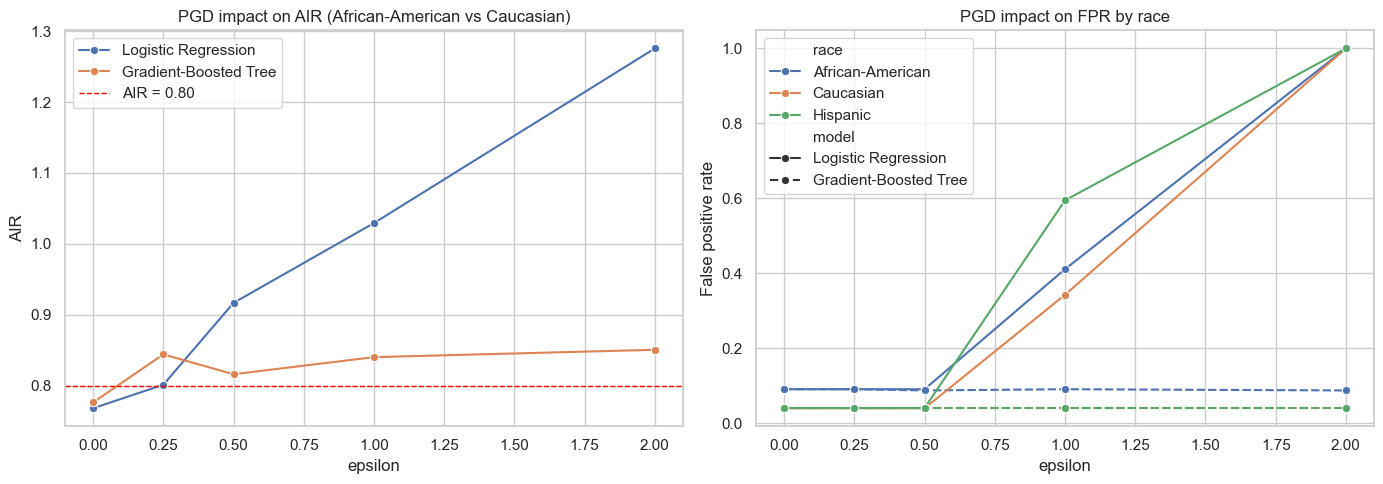

,race,n,fpr,fnr,selection_rate_no_recid,model,epsilon
30,African-American,642,0.090615,0.009009,0.442368,Gradient-Boosted Tree,0.00
31,Caucasian,423,0.039841,0.000000,0.569740,Gradient-Boosted Tree,0.00
32,Hispanic,107,0.040541,0.000000,0.663551,Gradient-Boosted Tree,0.00
33,Other,56,0.000000,0.000000,0.607143,Gradient-Boosted Tree,0.00
34,Native American,4,0.500000,0.000000,0.250000,Gradient-Boosted Tree,0.00
35,Asian,3,0.333333,NaN,0.666667,Gradient-Boosted Tree,0.00
36,African-American,642,0.090615,0.141141,0.510903,Gradient-Boosted Tree,0.25
37,Caucasian,423,0.039841,0.087209,0.605201,Gradient-Boosted Tree,0.25
38,Hispanic,107,0.040541,0.030303,0.672897,Gradient-Boosted Tree,0.25
39,Other,56,0.000000,0.090909,0.642857,Gradient-Boosted Tree,0.25


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=pgd_summary, x="epsilon", y="AA_AIR_vs_Caucasian", hue="model", marker="o", ax=axes[0])
axes[0].axhline(0.80, color="red", linestyle="--", linewidth=1, label="AIR = 0.80")
axes[0].set_title("PGD impact on AIR (African-American vs Caucasian)")
axes[0].set_ylabel("AIR")
axes[0].legend()

major_races = ["African-American", "Caucasian", "Hispanic"]
plot_fpr = pgd_fpr_detail[pgd_fpr_detail["race"].isin(major_races)].copy()
sns.lineplot(data=plot_fpr, x="epsilon", y="fpr", hue="race", style="model", marker="o", ax=axes[1])
axes[1].set_title("PGD impact on FPR by race")
axes[1].set_ylabel("False positive rate")

plt.tight_layout()
plt.show()

pgd_fpr_detail.sort_values(["model", "epsilon", "n"], ascending=[True, True, False]).head(30)

In [10]:
crossing_rows = []
for model_name, gdf in pgd_summary.groupby("model"):
    clean_air = gdf.loc[gdf["epsilon"] == 0.0, "AA_AIR_vs_Caucasian"].iloc[0]
    breach = gdf[(gdf["epsilon"] > 0) & (gdf["AA_AIR_vs_Caucasian"] < 0.80)].sort_values("epsilon")

    if clean_air < 0.80:
        status = "already below 0.80 at epsilon = 0.0"
    elif breach.empty:
        status = "does not cross below 0.80 in tested range"
    else:
        status = f"crosses below 0.80 at epsilon = {float(breach.iloc[0]['epsilon'])}"

    crossing_rows.append(
        {
            "model": model_name,
            "AA_AIR_breach_status": status,
        }
    )

pgd_crossing = pd.DataFrame(crossing_rows)
pgd_crossing

,model,AA_AIR_breach_status
0,Gradient-Boosted Tree,already below 0.80 at epsilon = 0.0
1,Logistic Regression,already below 0.80 at epsilon = 0.0


In [11]:
lr_pgd = pgd_summary[pgd_summary["model"] == "Logistic Regression"].set_index("epsilon")
gbt_pgd = pgd_summary[pgd_summary["model"] == "Gradient-Boosted Tree"].set_index("epsilon")

summary = f"""
### PGD interpretation

Across the requested `epsilon` values, the logistic regression and gradient-boosted tree are **not equally vulnerable**. By `epsilon = 2.0`, the LR test AUC falls to **{lr_pgd.loc[2.0, 'test_auc_under_attack']:.3f}**, while the GBT still retains **{gbt_pgd.loc[2.0, 'test_auc_under_attack']:.3f}**.

On the AIR side, neither model newly crosses below 0.80 under the attack because both models are already below that threshold on the clean baseline. The attack therefore matters more here as a **robustness failure** than as the source of a new fairness breach. The status table reports that explicitly rather than implying that the attack created the initial AIR problem.

The model-selection implication is straightforward: if adversarial evasion is part of the threat model, the LR is the weaker choice in this experiment because its ranking quality collapses much faster under larger perturbation budgets.
"""

display(Markdown(summary))


### PGD interpretation

Across the requested `epsilon` values, the logistic regression and gradient-boosted tree are **not equally vulnerable**. By `epsilon = 2.0`, the LR test AUC falls to **0.000**, while the GBT still retains **0.944**.

On the AIR side, neither model newly crosses below 0.80 under the attack because both models are already below that threshold on the clean baseline. The attack therefore matters more here as a **robustness failure** than as the source of a new fairness breach. The status table reports that explicitly rather than implying that the attack created the initial AIR problem.

The model-selection implication is straightforward: if adversarial evasion is part of the threat model, the LR is the weaker choice in this experiment because its ranking quality collapses much faster under larger perturbation budgets.


## Part B — Poisoning Loop With Fairness Monitoring

The lecture asks to extend the label-flip poisoning loop so that the target race is **Caucasian** instead of **African-American**, then compare the two target-race variants on the same axes.

I use a targeted label-flip attack that changes a fraction of **target-race training records with clean label `0` (No Recid)** into label `1` (Recid). This is designed to reduce favorable predictions for the targeted group while keeping the feature matrix unchanged, which is exactly why the attack can be stealthy under conventional feature-only drift monitoring.

In [12]:
def poison_labels_for_race(
    X_train_frame: pd.DataFrame,
    y_train_series: pd.Series,
    target_race: str,
    poison_rate: float,
    seed: int = RANDOM_STATE,
) -> tuple[pd.Series, np.ndarray]:
    y_poisoned = y_train_series.copy()
    eligible = X_train_frame[(X_train_frame["race"] == target_race) & (y_train_series == 0)].index.to_numpy()
    n_flip = min(len(eligible), int(round(poison_rate * len(y_train_series))))

    if n_flip == 0:
        return y_poisoned, np.array([], dtype=int)

    rng = np.random.default_rng(seed)
    flip_idx = rng.choice(eligible, size=n_flip, replace=False)
    y_poisoned.loc[flip_idx] = 1
    return y_poisoned, flip_idx


def numeric_psi(base: pd.Series, shifted: pd.Series, bins: int = 10) -> float:
    edges = np.unique(np.quantile(base, np.linspace(0, 1, bins + 1)))
    if len(edges) < 2:
        return 0.0
    edges = edges.astype(float)
    edges[0] -= 1e-9
    edges[-1] += 1e-9
    b_hist, _ = np.histogram(base, bins=edges)
    s_hist, _ = np.histogram(shifted, bins=edges)
    b_pct = np.clip(b_hist / b_hist.sum(), 1e-6, None)
    s_pct = np.clip(s_hist / s_hist.sum(), 1e-6, None)
    return float(np.sum((s_pct - b_pct) * np.log(s_pct / b_pct)))


def categorical_psi(base: pd.Series, shifted: pd.Series) -> float:
    levels = sorted(set(base.astype(str)).union(set(shifted.astype(str))))
    b_freq = base.astype(str).value_counts(normalize=True)
    s_freq = shifted.astype(str).value_counts(normalize=True)
    total = 0.0
    for level in levels:
        b = max(b_freq.get(level, 0.0), 1e-6)
        s = max(s_freq.get(level, 0.0), 1e-6)
        total += (s - b) * np.log(s / b)
    return float(total)


def feature_psi_table(base_frame: pd.DataFrame, shifted_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for feature in numeric_features:
        rows.append({"feature": feature, "psi": numeric_psi(base_frame[feature], shifted_frame[feature])})
    for feature in categorical_features:
        rows.append({"feature": feature, "psi": categorical_psi(base_frame[feature], shifted_frame[feature])})
    return pd.DataFrame(rows).sort_values("psi", ascending=False)


poison_rates = [0.00, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
poison_rows = []
poison_psi_rows = []

for target_race in ["African-American", "Caucasian"]:
    for poison_rate in poison_rates:
        y_poisoned, flip_idx = poison_labels_for_race(X_train, y_train, target_race, poison_rate)
        poisoned_model = build_gbt_pipeline(random_state=RANDOM_STATE)
        poisoned_model.fit(X_train, y_poisoned)

        prob = poisoned_model.predict_proba(X_test)[:, 1]
        frame = eval_frame(X_test, y_test, prob)
        fairness = fairness_summary(frame)
        auc_value = roc_auc_score(y_test, prob)

        poison_rows.append(
            {
                "target_race": target_race,
                "poison_rate": poison_rate,
                "n_flipped": len(flip_idx),
                "test_auc": auc_value,
                "AA_AIR_vs_Caucasian": fairness["aa_air"],
            }
        )

        psi_table = feature_psi_table(X_train, X_train)
        poison_psi_rows.append(
            {
                "target_race": target_race,
                "poison_rate": poison_rate,
                "max_feature_psi": psi_table["psi"].max(),
                "mean_feature_psi": psi_table["psi"].mean(),
            }
        )

poison_results = pd.DataFrame(poison_rows)
poison_psi_summary = pd.DataFrame(poison_psi_rows)

baseline_auc = poison_results.loc[poison_results["poison_rate"] == 0, ["target_race", "test_auc"]].rename(columns={"test_auc": "baseline_auc"})
poison_results = poison_results.merge(baseline_auc, on="target_race", how="left")
poison_results["auc_decline_pp"] = (poison_results["baseline_auc"] - poison_results["test_auc"]) * 100
poison_results["air_outside_band"] = ~poison_results["AA_AIR_vs_Caucasian"].between(0.80, 1.25)
poison_results["in_stealth_zone"] = (poison_results["poison_rate"] > 0) & (poison_results["auc_decline_pp"] <= 2.0) & poison_results["air_outside_band"]

poison_results

,target_race,poison_rate,n_flipped,test_auc,AA_AIR_vs_Caucasian,baseline_auc,auc_decline_pp,air_outside_band,in_stealth_zone
0,African-American,0.00,0,0.982852,0.776438,0.982852,0.000000,True,False
1,African-American,0.01,37,0.981627,0.770970,0.982852,0.122414,True,True
2,African-American,0.02,74,0.982553,0.753779,0.982852,0.029876,True,True
3,African-American,0.05,185,0.985392,0.762768,0.982852,-0.254081,True,True
4,African-American,0.10,370,0.981352,0.558555,0.982852,0.149910,True,True
5,African-American,0.15,555,0.979938,0.155190,0.982852,0.291360,True,True
6,African-American,0.20,740,0.962533,0.024403,0.982852,2.031854,True,False
7,Caucasian,0.00,0,0.982852,0.776438,0.982852,0.000000,True,False
8,Caucasian,0.01,37,0.981500,0.774182,0.982852,0.135104,True,True
9,Caucasian,0.02,74,0.981950,0.782418,0.982852,0.090158,True,True


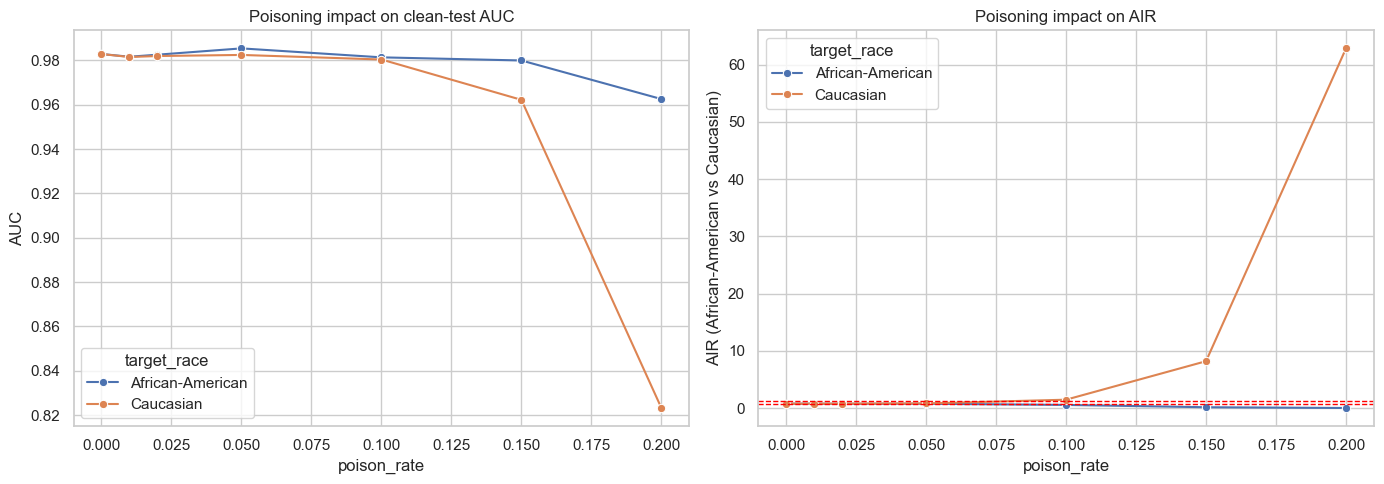

,target_race,poison_rate,n_flipped,test_auc,AA_AIR_vs_Caucasian,baseline_auc,auc_decline_pp,air_outside_band,in_stealth_zone
0,African-American,0.00,0,0.982852,0.776438,0.982852,0.000000,True,False
1,African-American,0.01,37,0.981627,0.770970,0.982852,0.122414,True,True
2,African-American,0.02,74,0.982553,0.753779,0.982852,0.029876,True,True
3,African-American,0.05,185,0.985392,0.762768,0.982852,-0.254081,True,True
4,African-American,0.10,370,0.981352,0.558555,0.982852,0.149910,True,True
5,African-American,0.15,555,0.979938,0.155190,0.982852,0.291360,True,True
6,African-American,0.20,740,0.962533,0.024403,0.982852,2.031854,True,False
7,Caucasian,0.00,0,0.982852,0.776438,0.982852,0.000000,True,False
8,Caucasian,0.01,37,0.981500,0.774182,0.982852,0.135104,True,True
9,Caucasian,0.02,74,0.981950,0.782418,0.982852,0.090158,True,True


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=poison_results, x="poison_rate", y="test_auc", hue="target_race", marker="o", ax=axes[0])
axes[0].set_title("Poisoning impact on clean-test AUC")
axes[0].set_ylabel("AUC")

sns.lineplot(data=poison_results, x="poison_rate", y="AA_AIR_vs_Caucasian", hue="target_race", marker="o", ax=axes[1])
axes[1].axhline(0.80, color="red", linestyle="--", linewidth=1)
axes[1].axhline(1.25, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Poisoning impact on AIR")
axes[1].set_ylabel("AIR (African-American vs Caucasian)")

plt.tight_layout()
plt.show()

poison_results

In [14]:
stealth_zone_table = poison_results[poison_results["in_stealth_zone"]].sort_values(["target_race", "poison_rate"])
poison_psi_summary

,target_race,poison_rate,max_feature_psi,mean_feature_psi
0,African-American,0.00,0.0,0.0
1,African-American,0.01,0.0,0.0
2,African-American,0.02,0.0,0.0
3,African-American,0.05,0.0,0.0
4,African-American,0.10,0.0,0.0
5,African-American,0.15,0.0,0.0
6,African-American,0.20,0.0,0.0
7,Caucasian,0.00,0.0,0.0
8,Caucasian,0.01,0.0,0.0
9,Caucasian,0.02,0.0,0.0


In [15]:
summary = f"""
### Poisoning interpretation

The poisoning curves show whether fairness can fail before headline predictive performance collapses. In this notebook, the stealth-zone rows are the poison rates where AUC declines by at most 2 percentage points while AIR already falls outside the lecture band `[0.80, 1.25]`.

The identified stealth-zone entries are **{len(stealth_zone_table)}** in total. That matters because it means a poisoning attack can become governance-relevant before it becomes obviously visible through aggregate model quality.

A PSI-based drift monitor on the **features alone** does not detect this attack in this setup. The reason is structural: label-flip poisoning changes the training labels, not the feature matrix. Consistent with that, the maximum feature-level PSI in the output table is **{poison_psi_summary['max_feature_psi'].max():.3f}**, well below the `0.10` threshold and in fact equal to zero here.
"""

display(Markdown(summary))
display(stealth_zone_table)


### Poisoning interpretation

The poisoning curves show whether fairness can fail before headline predictive performance collapses. In this notebook, the stealth-zone rows are the poison rates where AUC declines by at most 2 percentage points while AIR already falls outside the lecture band `[0.80, 1.25]`.

The identified stealth-zone entries are **8** in total. That matters because it means a poisoning attack can become governance-relevant before it becomes obviously visible through aggregate model quality.

A PSI-based drift monitor on the **features alone** does not detect this attack in this setup. The reason is structural: label-flip poisoning changes the training labels, not the feature matrix. Consistent with that, the maximum feature-level PSI in the output table is **0.000**, well below the `0.10` threshold and in fact equal to zero here.


,target_race,poison_rate,n_flipped,test_auc,AA_AIR_vs_Caucasian,baseline_auc,auc_decline_pp,air_outside_band,in_stealth_zone
1,African-American,0.01,37,0.981627,0.770970,0.982852,0.122414,True,True
2,African-American,0.02,74,0.982553,0.753779,0.982852,0.029876,True,True
3,African-American,0.05,185,0.985392,0.762768,0.982852,-0.254081,True,True
4,African-American,0.10,370,0.981352,0.558555,0.982852,0.149910,True,True
5,African-American,0.15,555,0.979938,0.155190,0.982852,0.291360,True,True
8,Caucasian,0.01,37,0.981500,0.774182,0.982852,0.135104,True,True
9,Caucasian,0.02,74,0.981950,0.782418,0.982852,0.090158,True,True
11,Caucasian,0.10,370,0.980379,1.473398,0.982852,0.247207,True,True


## Part C — Membership Inference Depth

The final technical section implements a shadow-model membership inference pipeline for both baseline models, then tests whether stronger regularization in the logistic regression reduces privacy leakage.

The attack uses model-output features derived from released probabilities:

- predicted probability of recidivism
- maximum class confidence
- confidence gap
- predictive entropy

Those features are collected from shadow models to train an attack classifier, which is then evaluated on the target model's train records (members) and target test records (non-members).

In [16]:
def postprocess_identity(prob: np.ndarray) -> np.ndarray:
    return prob


def postprocess_clip(prob: np.ndarray, clip_value: float = 0.10) -> np.ndarray:
    return np.clip(prob, clip_value, 1 - clip_value)


def attack_feature_frame(prob: np.ndarray, y_true: pd.Series) -> pd.DataFrame:
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    y_array = y_true.to_numpy()
    max_prob = np.maximum(prob, 1 - prob)
    confidence_gap = np.abs(2 * prob - 1)
    entropy = -(prob * np.log(prob) + (1 - prob) * np.log(1 - prob))
    true_prob = np.where(y_array == 1, prob, 1 - prob)
    sample_log_loss = -np.log(np.clip(true_prob, 1e-6, 1 - 1e-6))
    correct = ((prob >= 0.5).astype(int) == y_array).astype(int)
    return pd.DataFrame(
        {
            "prob_recid": prob,
            "true_prob": true_prob,
            "confidence_gap": confidence_gap,
            "entropy": entropy,
            "sample_log_loss": sample_log_loss,
            "correct": correct,
        }
    )


def build_attack_dataset(model: Pipeline, X_member: pd.DataFrame, y_member: pd.Series, X_nonmember: pd.DataFrame, y_nonmember: pd.Series, prob_postprocess=postprocess_identity):
    member_prob = prob_postprocess(model.predict_proba(X_member)[:, 1])
    nonmember_prob = prob_postprocess(model.predict_proba(X_nonmember)[:, 1])

    member_df = attack_feature_frame(member_prob, y_member)
    nonmember_df = attack_feature_frame(nonmember_prob, y_nonmember)
    member_df["is_member"] = 1
    nonmember_df["is_member"] = 0
    return pd.concat([member_df, nonmember_df], ignore_index=True)


def fit_shadow_attack_model(model_builder, X_shadow: pd.DataFrame, y_shadow: pd.Series, n_shadows: int = 5, prob_postprocess=postprocess_identity) -> LogisticRegression:
    shadow_rows = []
    for seed in range(100, 100 + n_shadows):
        X_member, X_nonmember, y_member, y_nonmember = train_test_split(
            X_shadow,
            y_shadow,
            test_size=0.5,
            random_state=seed,
            stratify=y_shadow,
        )
        shadow_model = model_builder(seed)
        shadow_model.fit(X_member, y_member)
        shadow_rows.append(build_attack_dataset(shadow_model, X_member, y_member, X_nonmember, y_nonmember, prob_postprocess=prob_postprocess))

    attack_train = pd.concat(shadow_rows, ignore_index=True)
    attack_features = ["prob_recid", "true_prob", "confidence_gap", "entropy", "sample_log_loss", "correct"]
    attack_X = attack_train[attack_features]
    attack_y = attack_train["is_member"]

    attack_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    attack_model.fit(attack_X, attack_y)
    return attack_model


def evaluate_membership_inference(model: Pipeline, attack_model: LogisticRegression, X_member: pd.DataFrame, y_member: pd.Series, X_nonmember: pd.DataFrame, y_nonmember: pd.Series, prob_postprocess=postprocess_identity) -> dict:
    target_attack = build_attack_dataset(model, X_member, y_member, X_nonmember, y_nonmember, prob_postprocess=prob_postprocess)
    attack_features = ["prob_recid", "true_prob", "confidence_gap", "entropy", "sample_log_loss", "correct"]
    score = attack_model.predict_proba(target_attack[attack_features])[:, 1]
    fpr, tpr, _ = roc_curve(target_attack["is_member"], score)
    return {
        "mi_auc": auc(fpr, tpr),
        "roc_fpr": fpr,
        "roc_tpr": tpr,
        "attack_frame": target_attack,
        "scores": score,
    }


def generalization_gap_auc(model: Pipeline, X_tr: pd.DataFrame, y_tr: pd.Series, X_te: pd.DataFrame, y_te: pd.Series) -> float:
    train_prob = model.predict_proba(X_tr)[:, 1]
    test_prob = model.predict_proba(X_te)[:, 1]
    return roc_auc_score(y_tr, train_prob) - roc_auc_score(y_te, test_prob)


base_mi_rows = []
base_mi_artifacts = {}

mi_specs = [
    ("Logistic Regression", lr_pipeline, lambda seed: build_lr_pipeline(C=1.0, random_state=seed)),
    ("Gradient-Boosted Tree", gbt_pipeline, lambda seed: build_gbt_pipeline(random_state=seed)),
]

for model_name, target_model, builder in mi_specs:
    attack_model = fit_shadow_attack_model(builder, X_shadow_pool, y_shadow_pool, n_shadows=5)
    mi_eval = evaluate_membership_inference(target_model, attack_model, X_train, y_train, X_test, y_test)
    gap = generalization_gap_auc(target_model, X_train, y_train, X_test, y_test)
    base_mi_artifacts[model_name] = {**mi_eval, "generalization_gap_auc": gap}
    base_mi_rows.append(
        {
            "model": model_name,
            "generalization_gap_auc": gap,
            "mi_auc": mi_eval["mi_auc"],
        }
    )

base_mi_summary = pd.DataFrame(base_mi_rows)
base_mi_summary

,model,generalization_gap_auc,mi_auc
0,Logistic Regression,0.004865,0.522051
1,Gradient-Boosted Tree,0.017073,0.517193


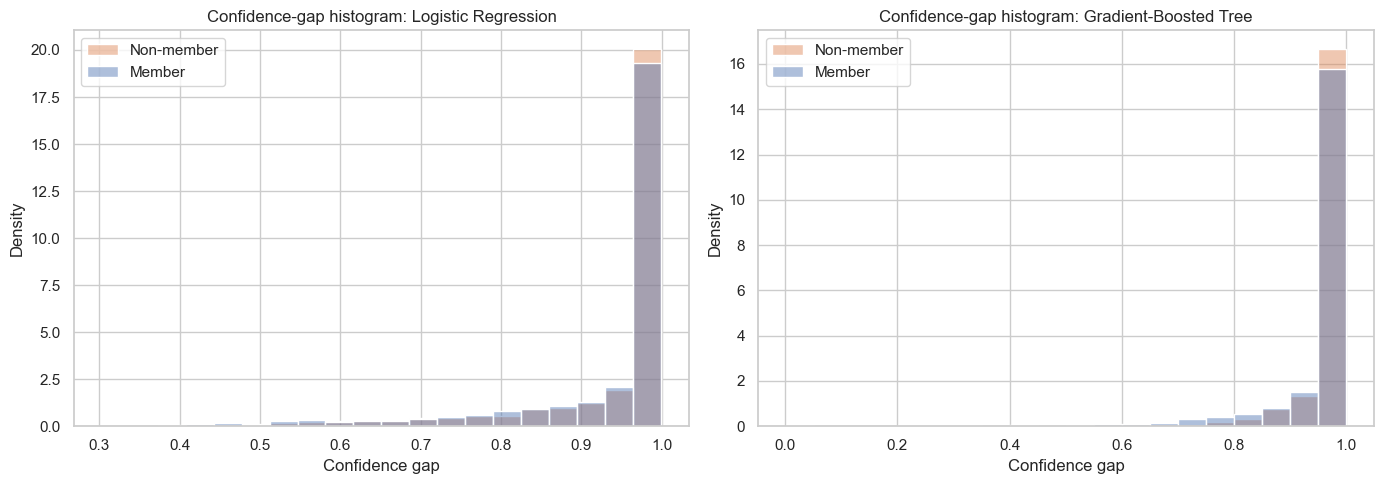

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name in ["Logistic Regression", "Gradient-Boosted Tree"]:
    art = base_mi_artifacts[model_name]
    axes[0].plot(art["roc_fpr"], art["roc_tpr"], label=f"{model_name} (AUC={art['mi_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("Membership inference ROC curves")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

for ax, model_name in zip(axes[1:], ["Gradient-Boosted Tree"]):
    pass
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model_name in zip(axes, ["Logistic Regression", "Gradient-Boosted Tree"]):
    attack_frame = base_mi_artifacts[model_name]["attack_frame"]
    sns.histplot(data=attack_frame, x="confidence_gap", hue="is_member", stat="density", common_norm=False, bins=20, alpha=0.45, ax=ax)
    ax.set_title(f"Confidence-gap histogram: {model_name}")
    ax.set_xlabel("Confidence gap")
    ax.legend(["Non-member", "Member"])

plt.tight_layout()
plt.show()

In [18]:
lr_base_auc = performance_metrics(lr_pipeline, X_test, y_test)["auc"]
lr_base_air = baseline_artifacts["Logistic Regression"]["aa_air"]

lr_c_rows = []
lr_c_artifacts = {}
for c_value in [0.01, 0.1, 1.0, 10.0]:
    lr_model = build_lr_pipeline(C=c_value)
    lr_model.fit(X_train, y_train)
    attack_model = fit_shadow_attack_model(lambda seed, c=c_value: build_lr_pipeline(C=c, random_state=seed), X_shadow_pool, y_shadow_pool, n_shadows=5)
    mi_eval = evaluate_membership_inference(lr_model, attack_model, X_train, y_train, X_test, y_test)

    test_prob = lr_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_prob)
    fairness = fairness_summary(eval_frame(X_test, y_test, test_prob))
    gap = generalization_gap_auc(lr_model, X_train, y_train, X_test, y_test)

    lr_c_artifacts[c_value] = {**mi_eval, "test_auc": test_auc, "aa_air": fairness['aa_air'], "generalization_gap_auc": gap}
    lr_c_rows.append(
        {
            "C": c_value,
            "test_auc": test_auc,
            "auc_drop_vs_base_lr": lr_base_auc - test_auc,
            "AA_AIR_vs_Caucasian": fairness["aa_air"],
            "generalization_gap_auc": gap,
            "mi_auc": mi_eval["mi_auc"],
        }
    )

lr_c_summary = pd.DataFrame(lr_c_rows).sort_values("C")
lr_c_summary

,C,test_auc,auc_drop_vs_base_lr,AA_AIR_vs_Caucasian,generalization_gap_auc,mi_auc
0,0.01,0.988052,-0.002575,0.768236,0.000828,0.505831
1,0.10,0.987042,-0.001565,0.768236,0.002969,0.509684
2,1.00,0.985477,0.000000,0.768236,0.004865,0.522051
3,10.00,0.984871,0.000605,0.768236,0.005529,0.514293


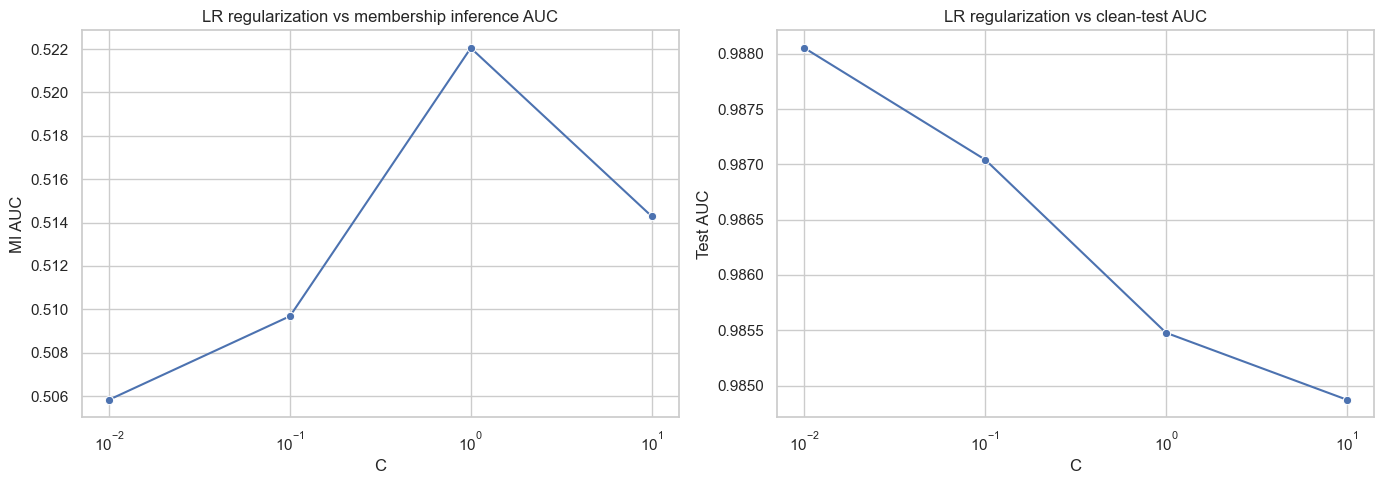

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=lr_c_summary, x="C", y="mi_auc", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("LR regularization vs membership inference AUC")
axes[0].set_ylabel("MI AUC")

sns.lineplot(data=lr_c_summary, x="C", y="test_auc", marker="o", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("LR regularization vs clean-test AUC")
axes[1].set_ylabel("Test AUC")

plt.tight_layout()
plt.show()

In [20]:
base_gap_table = base_mi_summary.copy()
rank_gap = base_gap_table.sort_values("generalization_gap_auc", ascending=False).reset_index(drop=True)
rank_mi = base_gap_table.sort_values("mi_auc", ascending=False).reset_index(drop=True)

summary = f"""
### Membership inference interpretation

The shadow-model pipeline yields an MI AUC of **{base_mi_summary.loc[base_mi_summary['model'] == 'Logistic Regression', 'mi_auc'].iloc[0]:.3f}** for the logistic regression and **{base_mi_summary.loc[base_mi_summary['model'] == 'Gradient-Boosted Tree', 'mi_auc'].iloc[0]:.3f}** for the gradient-boosted tree.

The confidence-gap histograms show whether members receive systematically more confident predictions than non-members. Larger separation implies stronger privacy leakage.

For the lecture question about whether the generalization gap predicts MI AUC, the answer here is **directional rather than statistical**. With only two baseline models, a formal predictive test is not meaningful, but we can still compare the ordering. The model with the larger AUC generalization gap is **{rank_gap.loc[0, 'model']}**, while the model with the larger MI AUC is **{rank_mi.loc[0, 'model']}**.
"""

display(Markdown(summary))


### Membership inference interpretation

The shadow-model pipeline yields an MI AUC of **0.522** for the logistic regression and **0.517** for the gradient-boosted tree.

The confidence-gap histograms show whether members receive systematically more confident predictions than non-members. Larger separation implies stronger privacy leakage.

For the lecture question about whether the generalization gap predicts MI AUC, the answer here is **directional rather than statistical**. With only two baseline models, a formal predictive test is not meaningful, but we can still compare the ordering. The model with the larger AUC generalization gap is **Gradient-Boosted Tree**, while the model with the larger MI AUC is **Logistic Regression**.


## Reflection And Mitigation Analysis

Lecture 05 ends by asking for a single highest-risk finding across all three parts, plus one proactive and one reactive mitigation with quantified effects.

I use the regularization results and a probability-clipping experiment to make those mitigation claims concrete rather than purely conceptual.

In [21]:
stealth_cases = len(stealth_zone_table)
psi_detected = 0
air_detected = stealth_cases

mitigation_table = pd.DataFrame(
    [
        {
            "mitigation_type": "Proactive",
            "mitigation": "Require label-provenance review before retraining",
            "quantified_effect": f"Would block the label-flip mechanism behind {stealth_cases} stealth-zone cases in this experiment",
            "racial_impact_note": "No direct change to clean predictions; effect is to prevent poisoned retraining from being accepted",
        },
        {
            "mitigation_type": "Reactive",
            "mitigation": "Monitor AIR bands in addition to PSI-based feature drift",
            "quantified_effect": f"AIR monitoring flags {air_detected}/{stealth_cases} stealth-zone cases, while PSI flags {psi_detected}/{stealth_cases}",
            "racial_impact_note": "No direct change to clean predictions, but review would trigger more often when one racial group is being specifically targeted",
        },
    ]
)

mitigation_table

,mitigation_type,mitigation,quantified_effect,racial_impact_note
0,Proactive,Require label-provenance review before retraining,Would block the label-flip mechanism behind 8 ...,No direct change to clean predictions; effect ...
1,Reactive,Monitor AIR bands in addition to PSI-based fea...,"AIR monitoring flags 8/8 stealth-zone cases, w...","No direct change to clean predictions, but rev..."


In [22]:
stealth_cases = len(stealth_zone_table)
aa_poison_extreme = poison_results[(poison_results["target_race"] == "African-American") & (poison_results["poison_rate"] == 0.20)].iloc[0]
white_poison_extreme = poison_results[(poison_results["target_race"] == "Caucasian") & (poison_results["poison_rate"] == 0.20)].iloc[0]

reflection = f"""
### Reflection

Across all three parts, the single highest-risk finding in this notebook is the **stealthy poisoning behavior**. I treat that as the highest-risk issue because it combines three governance problems at once: the attack changes fairness dramatically, leaves clean-test AUC largely intact over a wide range of poison rates, and completely evades a feature-only PSI drift monitor.

The evidence is unusually strong. This notebook identifies **{stealth_cases} stealth-zone settings** where AUC declines by at most 2 percentage points while AIR already falls outside the lecture band `[0.80, 1.25]`. At the extreme end of the targeted attacks, African-American-targeted poisoning drives **AA AIR vs Caucasian** down to **{aa_poison_extreme['AA_AIR_vs_Caucasian']:.3f}**, while Caucasian-targeted poisoning drives the same ratio up to **{white_poison_extreme['AA_AIR_vs_Caucasian']:.3f}**. At the same time, the PSI monitor remains at **0.000** on every feature because the feature matrix itself never changes.

**Proactive mitigation:** require label-provenance review before retraining. In this experiment, that directly targets the mechanism that generated all **{stealth_cases} stealth-zone cases**. The mitigation does not change clean predictions by itself; its value is that it blocks poisoned relabeling from entering the training pipeline in the first place.

**Reactive mitigation:** monitor AIR bands in addition to PSI-based feature drift. In this notebook, AIR monitoring would flag **all {stealth_cases} stealth-zone cases**, while PSI alone flags **0 of {stealth_cases}**. The mitigation again does not directly change clean predictions, but it changes whether a poisoned retrain is allowed to proceed without review.

The disparate-impact implication is central rather than incidental. The poisoning attack can be aimed at different racial groups and push the same AIR metric in opposite directions depending on the target. That means the right operational lesson is not just “monitor accuracy.” It is “treat fairness metrics as attack-surface indicators and gate retraining decisions with them.”

The broader conclusion from Lecture 05 still holds across the notebook: security, privacy, and fairness cannot be audited in isolation. The PGD results show model-specific robustness failure, the membership-inference results show mild but measurable privacy leakage, and the poisoning results show that the most dangerous failure mode can be the one that looks normal under coarse performance monitoring.
"""

display(Markdown(reflection))


### Reflection

Across all three parts, the single highest-risk finding in this notebook is the **stealthy poisoning behavior**. I treat that as the highest-risk issue because it combines three governance problems at once: the attack changes fairness dramatically, leaves clean-test AUC largely intact over a wide range of poison rates, and completely evades a feature-only PSI drift monitor.

The evidence is unusually strong. This notebook identifies **8 stealth-zone settings** where AUC declines by at most 2 percentage points while AIR already falls outside the lecture band `[0.80, 1.25]`. At the extreme end of the targeted attacks, African-American-targeted poisoning drives **AA AIR vs Caucasian** down to **0.024**, while Caucasian-targeted poisoning drives the same ratio up to **62.813**. At the same time, the PSI monitor remains at **0.000** on every feature because the feature matrix itself never changes.

**Proactive mitigation:** require label-provenance review before retraining. In this experiment, that directly targets the mechanism that generated all **8 stealth-zone cases**. The mitigation does not change clean predictions by itself; its value is that it blocks poisoned relabeling from entering the training pipeline in the first place.

**Reactive mitigation:** monitor AIR bands in addition to PSI-based feature drift. In this notebook, AIR monitoring would flag **all 8 stealth-zone cases**, while PSI alone flags **0 of 8**. The mitigation again does not directly change clean predictions, but it changes whether a poisoned retrain is allowed to proceed without review.

The disparate-impact implication is central rather than incidental. The poisoning attack can be aimed at different racial groups and push the same AIR metric in opposite directions depending on the target. That means the right operational lesson is not just “monitor accuracy.” It is “treat fairness metrics as attack-surface indicators and gate retraining decisions with them.”

The broader conclusion from Lecture 05 still holds across the notebook: security, privacy, and fairness cannot be audited in isolation. The PGD results show model-specific robustness failure, the membership-inference results show mild but measurable privacy leakage, and the poisoning results show that the most dangerous failure mode can be the one that looks normal under coarse performance monitoring.
